In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

Number of experimental points: 244
Number of model points: 48
Number of overlapping fit points: 244
Best scale factor: 0.00011551372039418287
Minimum error: 1576.4025466447874


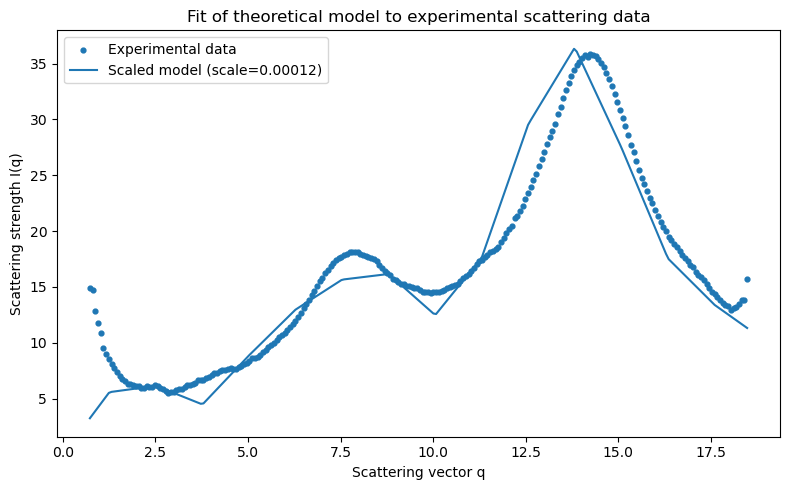

In [8]:
# Load arrays
# Two columns
# 1st column: scattering vector q
# 2nd column: scattering strength I(q)
exp_data = np.load("I_q_IPA_exp.npy")
model_data = np.load("I_q_IPA_model.npy")

# Split columns

# Experimental 
q_exp = exp_data[:, 0]
I_exp = exp_data[:, 1]

# Model
q_model = model_data[:, 0]
I_model = model_data[:, 1]

# Clean before fitting by removing nan
exp_mask = np.isfinite(q_exp) & np.isfinite(I_exp)
model_mask = np.isfinite(q_model) & np.isfinite(I_model)

q_exp = q_exp[exp_mask]
I_exp = I_exp[exp_mask]

q_model = q_model[model_mask]
I_model = I_model[model_mask]

# Keep only overlapping q range
overlap_mask = (q_exp >= q_model.min()) & (q_exp <= q_model.max())
q_exp_overlap = q_exp[overlap_mask]
I_exp_overlap = I_exp[overlap_mask]

# Interpolate model onto experimental q values
f_model = interp1d(q_model, I_model, kind="linear", bounds_error=False, fill_value=np.nan)
I_model_interp = f_model(q_exp_overlap)

# Remove any nans created by interpolation
valid_mask = np.isfinite(I_model_interp) & np.isfinite(I_exp_overlap)
q_fit = q_exp_overlap[valid_mask]
I_exp_fit = I_exp_overlap[valid_mask]
I_model_fit = I_model_interp[valid_mask]

print("Number of experimental points:", len(q_exp))
print("Number of model points:", len(q_model))
print("Number of overlapping fit points:", len(q_fit))

# Objective function
def objective(scale):
    return np.sum((I_exp_fit - scale * I_model_fit) ** 2)

# Restrict search to positive scaling factors
result = minimize_scalar(objective, bounds=(0, 100), method="bounded")

best_scale = result.x
print("Best scale factor:", best_scale)
print("Minimum error:", result.fun)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(q_exp, I_exp, s=12, label="Experimental data")
plt.plot(q_fit, best_scale * I_model_fit, label=f"Scaled model (scale={best_scale:.5f})")

plt.xlabel("Scattering vector q")
plt.ylabel("Scattering strength I(q)")
plt.title("Fit of theoretical model to experimental scattering data")
plt.legend()
plt.tight_layout()
plt.show()